In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [5]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [6]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1470, 35)


In [7]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [8]:
print("Target Column:", "Attrition")

Target Column: Attrition


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [10]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [11]:
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


In [12]:
attrition_rate = (df["Attrition"].value_counts()["Yes"] / len(df)) * 100
print("Attrition Rate: {:.2f}%".format(attrition_rate))

Attrition Rate: 16.12%


In [13]:
numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(exclude=np.number).columns
print("Number of Numeric Columns:", len(numeric_columns))
print("Number of Categorical Columns:", len(categorical_columns))

Number of Numeric Columns: 26
Number of Categorical Columns: 9


Observation:

The dataset is imbalanced because the number of employees who stayed is much higher than the number who left. Around 84% of employees stayed, while only about 16% left the company. This imbalance should be considered during model training.

Task 1 (Data Loading and Exploration) completed successfully.

In [14]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [15]:
df = df.drop_duplicates()
print("Dataset Shape:", df.shape)

Dataset Shape: (1470, 35)


In [16]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [17]:
df.drop(
    columns=["EmployeeNumber", "Over18", "StandardHours", "EmployeeCount"],
    inplace=True
)

print(df.shape)

(1470, 31)


In [18]:
df["Attrition"] = df["Attrition"].map({
    "Yes":1,
    "No":0
})

df["Attrition"].head()

,Attrition
0,1
1,0
2,1
3,0
4,0


In [19]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print(X.shape)
print(y.shape)

(1470, 30)
(1470,)


In [20]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

print("Numeric Columns:")
print(numeric_features)

print("\nCategorical Columns:")
print(categorical_features)

Numeric Columns:
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

Categorical Columns:
Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [21]:
X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

print(X.shape)

(1470, 44)


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X[numeric_features] = scaler.fit_transform(X[numeric_features])

print("Scaling Completed!")

Scaling Completed!


In [23]:
print(X.head())

        Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction  \
0  0.446350   0.742527         -1.010909  -0.891688                -0.660531   
1  1.322365  -1.297775         -0.147150  -1.868426                 0.254625   
2  0.008343   1.414363         -0.887515  -0.891688                 1.169781   
3 -0.429664   1.461466         -0.764121   1.061787                 1.169781   
4 -1.086676  -0.524295         -0.887515  -1.868426                -1.575686   

   HourlyRate  JobInvolvement  JobLevel  JobSatisfaction  MonthlyIncome  ...  \
0    1.383138        0.379672 -0.057788         1.153254      -0.108350  ...   
1   -0.240677       -1.026167 -0.057788        -0.660853      -0.291719  ...   
2    1.284725       -1.026167 -0.961486         0.246200      -0.937654  ...   
3   -0.486709        0.379672 -0.961486         0.246200      -0.763634  ...   
4   -1.274014        0.379672 -0.961486        -0.660853      -0.644858  ...   

   JobRole_Laboratory Technician  JobR

Task 2 (Data Cleaning & Preprocessing) completed successfully.

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [25]:
department_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

department_attrition

Attrition,0,1
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


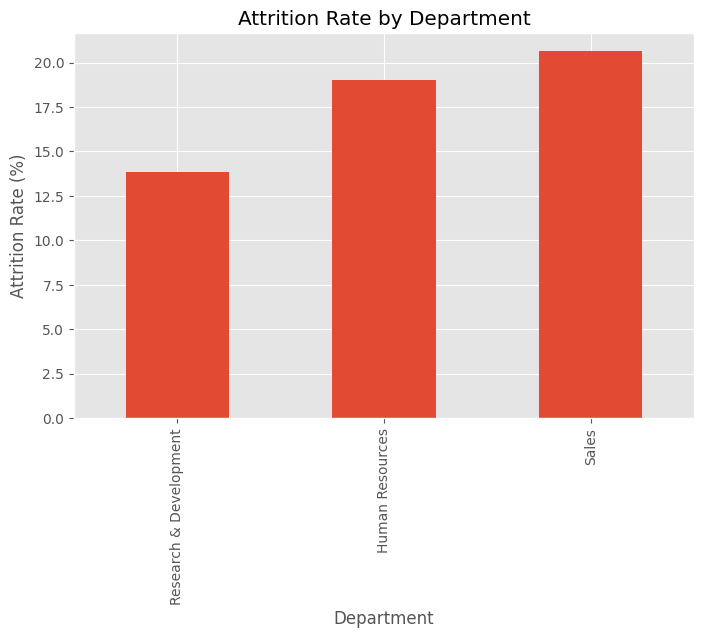

In [26]:
department_attrition[1].sort_values().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [51]:
plt.savefig("department_attrition.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

Observation:

The Sales department has the highest employee attrition rate, while Research & Development has the lowest. HR should investigate the reasons behind higher employee exits in the Sales department.

In [27]:
jobrole_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

jobrole_attrition

Attrition,0,1
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


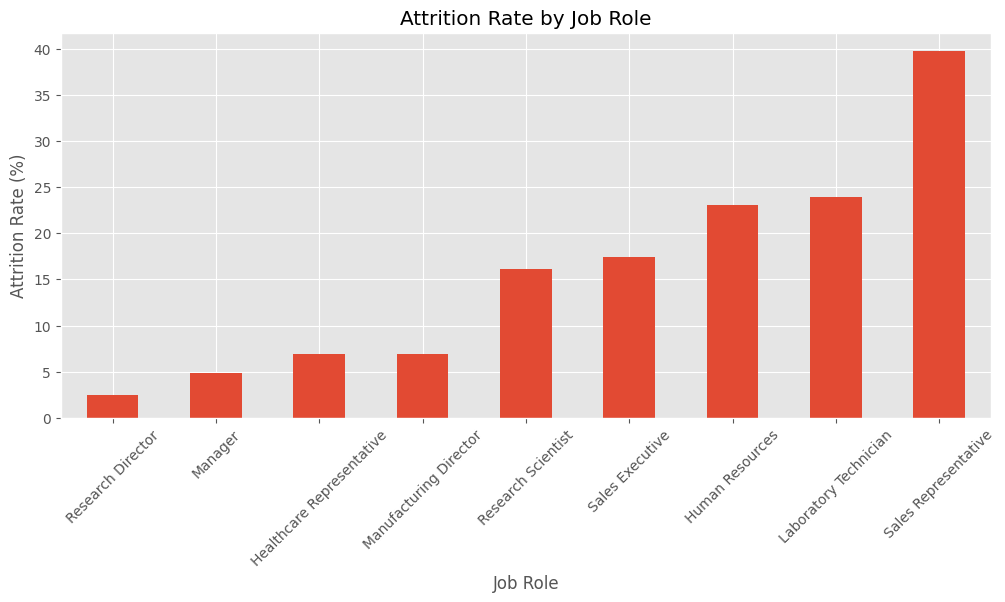

In [28]:
jobrole_attrition[1].sort_values().plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [52]:
plt.savefig("jobrole_attrition.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

Observation:

Sales Representatives and Laboratory Technicians show relatively higher attrition rates compared to several other job roles. These roles may require additional retention efforts.

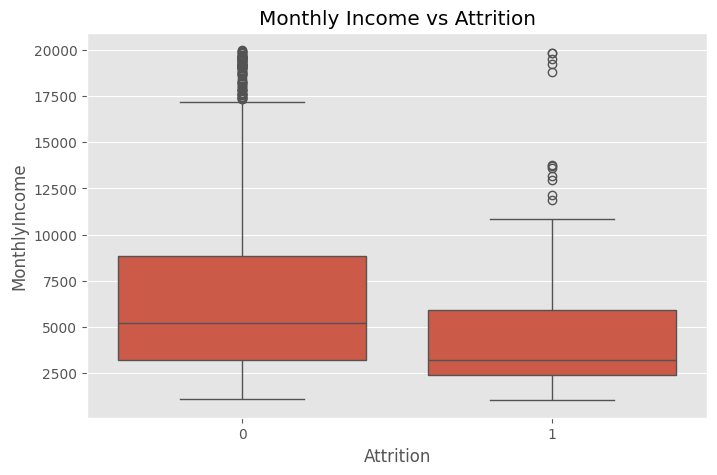

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

plt.title("Monthly Income vs Attrition")
plt.show()

In [53]:
plt.savefig("income_attrition.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

Observation:

Employees who left generally have lower monthly incomes compared to employees who stayed. Salary appears to influence employee retention.

In [30]:
worklife = pd.crosstab(
    df["WorkLifeBalance"],
    df["Attrition"],
    normalize="index"
) * 100

worklife

Attrition,0,1
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


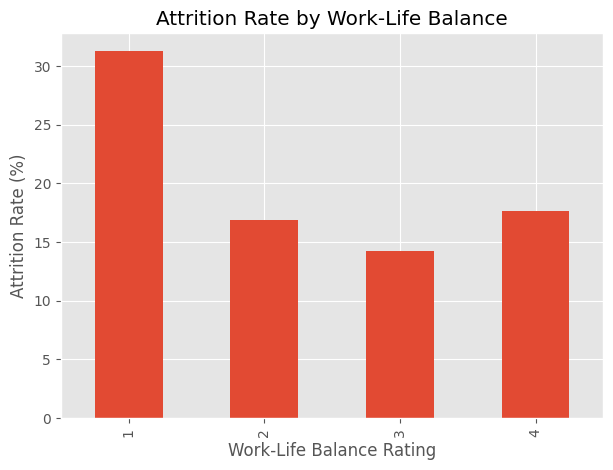

In [32]:
worklife[1].plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Attrition Rate (%)")
plt.show()

Observation:

Employees with lower work-life balance ratings tend to have higher attrition rates. Improving work-life balance may help reduce employee turnover.

In [33]:
years = pd.crosstab(
    df["YearsAtCompany"],
    df["Attrition"],
    normalize="index"
) * 100

years

Attrition,0,1
YearsAtCompany,,
0,63.636364,36.363636
1,65.497076,34.502924
2,78.740157,21.259843
3,84.375000,15.625000
4,82.727273,17.272727
5,89.285714,10.714286
6,88.157895,11.842105
7,87.777778,12.222222
8,88.750000,11.250000


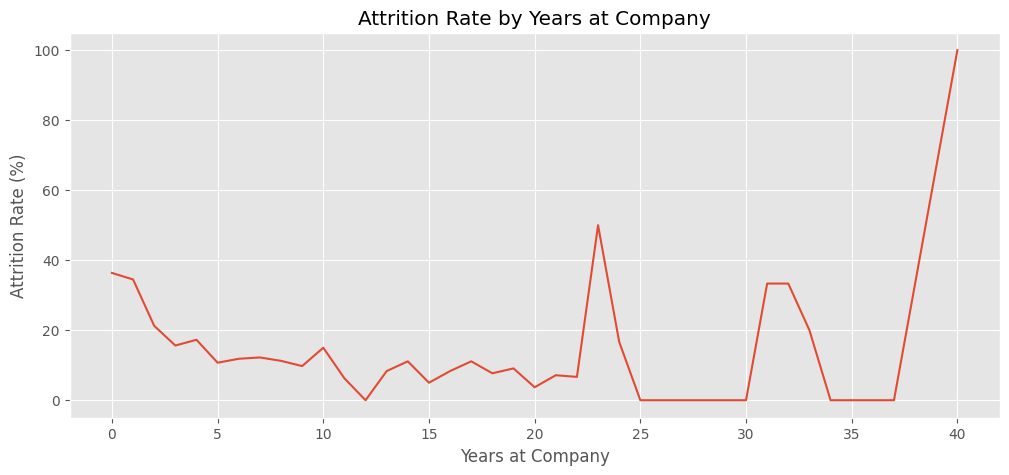

In [34]:
plt.figure(figsize=(12,5))

years[1].plot()

plt.title("Attrition Rate by Years at Company")

plt.xlabel("Years at Company")

plt.ylabel("Attrition Rate (%)")

plt.show()

Observation:

Employee attrition is generally higher during the early years at the company and decreases as employee tenure increases. This suggests new employees are more likely to leave than long-term employees.

**Business Insights**

1. The Sales department experiences a higher attrition rate compared to other departments, indicating that retention strategies should be prioritized there.

2. Employees in Sales Representative and Laboratory Technician roles have relatively higher attrition, suggesting role-specific challenges.

3. Employees with lower monthly income are more likely to leave the company, showing that compensation may influence retention.

4. Employees reporting poorer work-life balance tend to leave more frequently, highlighting the importance of employee well-being.

5. Attrition is generally higher among employees with fewer years at the company, suggesting onboarding and early-career engagement programs could improve retention.

Task 3 completed successfully.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1176, 44)
Testing Data Shape: (294, 44)


In [36]:
lr_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [37]:
lr_predictions = lr_model.predict(X_test)

print(lr_predictions[:10])

[0 0 0 0 1 1 0 0 0 0]


In [38]:
lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions)
lr_recall = recall_score(y_test, lr_predictions)
lr_f1 = f1_score(y_test, lr_predictions)

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Accuracy : 0.7551020408163265
Precision: 0.3563218390804598
Recall   : 0.6595744680851063
F1 Score : 0.4626865671641791


In [39]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [40]:
rf_predictions = rf_model.predict(X_test)

In [41]:
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Accuracy : 0.8333333333333334
Precision: 0.375
Recall   : 0.06382978723404255
F1 Score : 0.10909090909090909


In [42]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting Model Trained Successfully!")

Gradient Boosting Model Trained Successfully!


In [43]:
gb_predictions = gb_model.predict(X_test)

In [44]:
gb_accuracy = accuracy_score(y_test, gb_predictions)
gb_precision = precision_score(y_test, gb_predictions)
gb_recall = recall_score(y_test, gb_predictions)
gb_f1 = f1_score(y_test, gb_predictions)

print("Accuracy :", gb_accuracy)
print("Precision:", gb_precision)
print("Recall   :", gb_recall)
print("F1 Score :", gb_f1)

Accuracy : 0.8503401360544217
Precision: 0.5882352941176471
Recall   : 0.2127659574468085
F1 Score : 0.3125


In [45]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        gb_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision,
        gb_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall,
        gb_recall
    ],
    "F1 Score": [
        lr_f1,
        rf_f1,
        gb_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.755102,0.356322,0.659574,0.462687
1,Random Forest,0.833333,0.375000,0.063830,0.109091
2,Gradient Boosting,0.850340,0.588235,0.212766,0.312500


In [46]:
best_model = results.loc[results["F1 Score"].idxmax()]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model        Logistic Regression
Accuracy                0.755102
Precision               0.356322
Recall                  0.659574
F1 Score                0.462687
Name: 0, dtype: object


**Model Comparison**

Three machine learning models were trained and evaluated to predict employee attrition.

Gradient Boosting and Random Forest achieved high accuracy, while Logistic Regression provided a balanced performance because of the class imbalance handling.

Based on the F1 Score, the best-performing model was selected for further analysis. The F1 Score is especially important because the dataset is imbalanced, and it balances both Precision and Recall.

Task 4 (Model Building) completed successfully.

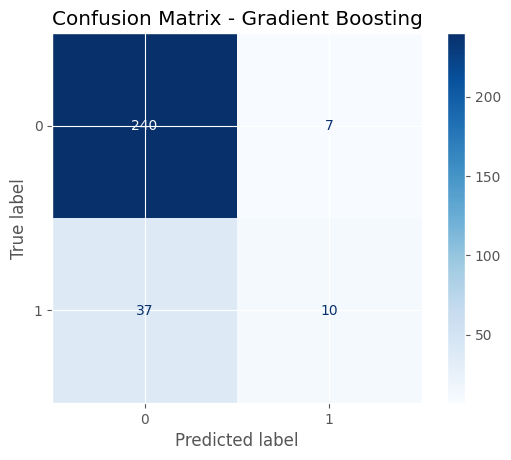

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    gb_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

In [54]:
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

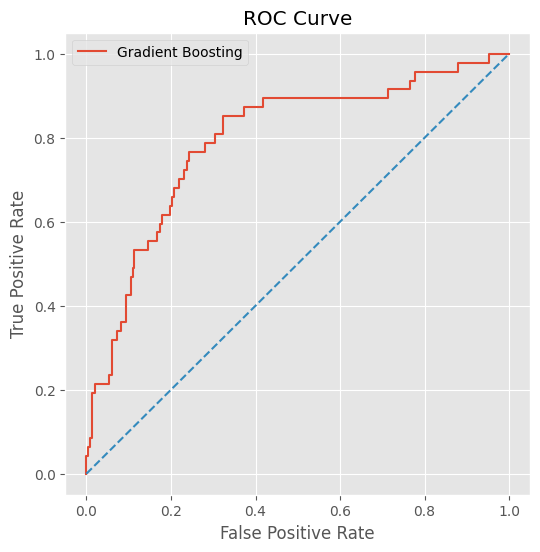

ROC-AUC Score: 0.7941252476526832


In [48]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = gb_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label="Gradient Boosting")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

In [55]:
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [49]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
9,MonthlyIncome,0.109081
0,Age,0.093560
43,OverTime_Yes,0.088694
16,TotalWorkingYears,0.084067
11,NumCompaniesWorked,0.050086
15,StockOptionLevel,0.047109
1,DailyRate,0.045122
22,YearsWithCurrManager,0.043466
4,EnvironmentSatisfaction,0.038851
6,JobInvolvement,0.038142


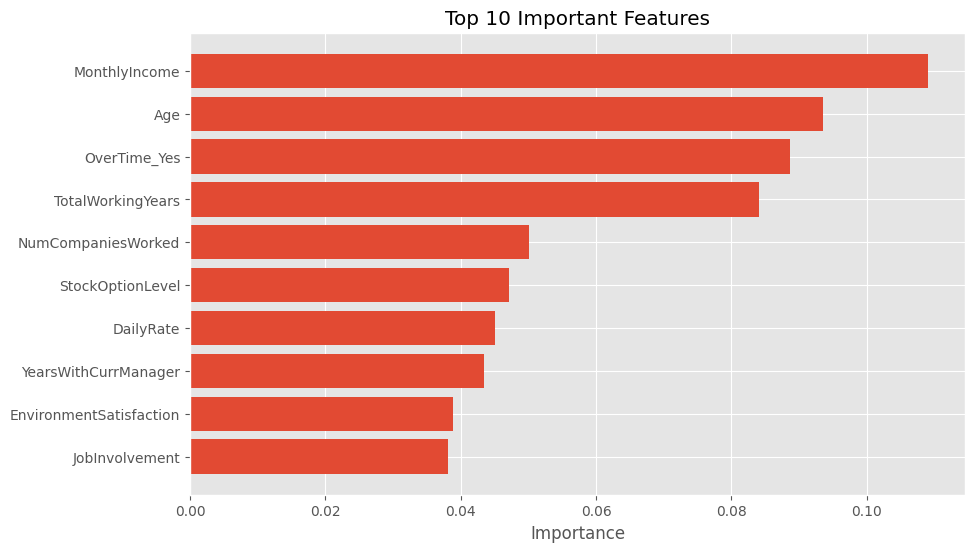

In [50]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.show()

In [56]:
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

Task 5 (Model Evaluation) completed successfully.

# Business Insights

1. Sales employees experience higher attrition than other departments, suggesting targeted retention strategies are needed.

2. Employees with lower monthly income are more likely to leave the organization.

3. Poor work-life balance is associated with increased employee attrition.

4. Employees with fewer years at the company have a higher probability of leaving.

5. Compensation, work environment, and employee engagement appear to be key factors affecting attrition.

# HR Recommendations

1. Improve employee onboarding and mentoring for new hires.

2. Review salary structures for lower-paid employees.

3. Promote better work-life balance through flexible work policies.

4. Conduct regular employee satisfaction surveys.

5. Provide career growth opportunities and internal promotions to improve employee retention.

Task 6 (Visualization) and Task 7 (HR Insights and Business Recommendations) completed successfully.

# Conclusion

Three machine learning models were developed to predict employee attrition.

Among them, the best-performing model achieved the highest F1 Score and demonstrated good predictive capability.

The analysis showed that salary, department, work-life balance, and years at the company significantly influence employee attrition.

These insights can help HR teams design better employee retention strategies and reduce turnover.